# Analyse RUL MOSFET par run + comparaison directe / power model + LSTM

Ce notebook suit une logique claire :

1. **Analyser l'évolution de `RDS_on` pour chaque run**.
2. **Lisser `RDS_on` avec EWMA**.
3. **Déterminer `N_fail` par deux méthodes** :
   - méthode directe : franchissement du seuil `1.2 × R0_local` sur la courbe lissée,
   - méthode power model : ajustement de `R(N) = R0 + k·N^β`.
4. **Choisir la RUL de la méthode directe comme cible d'apprentissage**, car ici on veut utiliser la RUL estimée directement à partir des données.
5. **Utiliser la méthode power model uniquement comme comparaison / diagnostic**.
6. **Construire un LSTM** et comparer plusieurs tailles de fenêtre : **5, 10, 15, 30**.
7. **Tracer les courbes RUL réelle vs RUL prédite** pour le jeu de test.

## Idée retenue pour la cible utilisée par le LSTM

Pour un run donné :

\[
RUL_{direct}(N) = N_{fail,direct} - N_{current}
\]

où `N_fail_direct` est le premier cycle pour lequel `RDS_on_EWMA` dépasse le seuil `1.2 × R0_local`
pendant plusieurs points consécutifs.

Important :
- **la RUL utilisée pour le LSTM est la RUL directe**,
- **la RUL issue du power model n'est pas utilisée comme cible**, elle sert seulement à comparer les deux approches.


In [1]:
# ==========================================================
# PARTIE 1 — IMPORTS ET REPRODUCTIBILITÉ
# ==========================================================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
# ==========================================================
# PARTIE 2 — CHEMIN DU FICHIER ET PARAMÈTRES
# ==========================================================
FILE_PATH = r"C:\Users\elvas\Downloads\Stage de recherche\extracted_test9_run1\Test_9_runs_1_to_3_cycle_agg_concat.csv"

# Fallback automatique si le chemin Windows n'existe pas dans l'environnement courant
if not os.path.exists(FILE_PATH):
    FILE_PATH = "/mnt/data/Test_9_runs_1_to_3_cycle_agg_concat.csv"

UNIT_COL = "run_id"
CYCLE_COL = "cycle_current"
RDS_COL = "RDS_on_raw_cycle"

# Paramètres d'analyse de la dégradation
R0_POINTS = 30
EWMA_ALPHA = 0.20
FAILURE_FACTOR = 1.20
CONSECUTIVE_POINTS = 3

# Paramètres de recherche d'hyperparamètres LSTM
WINDOW_SIZES = [5, 10, 15, 30]
LSTM_UNITS_GRID = [32, 64]
DROPOUT_GRID = [0.10, 0.20]
DENSE_UNITS_GRID = [16, 32]
LEARNING_RATE_GRID = [1e-3, 5e-4]
BATCH_SIZE_GRID = [16, 32]

EPOCHS_GRID = 60
EPOCHS_FINAL = 80
PATIENCE_ES = 12
PATIENCE_LR = 6
MAX_GRID_TRIALS = None   # mettre un entier si tu veux limiter le nombre de combinaisons testées

print("Fichier utilisé :", FILE_PATH)
print("UNIT_COL :", UNIT_COL)
print("CYCLE_COL:", CYCLE_COL)
print("RDS_COL  :", RDS_COL)
print("WINDOW_SIZES :", WINDOW_SIZES)


Fichier utilisé : C:\Users\elvas\Downloads\Stage de recherche\extracted_test9_run1\Test_9_runs_1_to_3_cycle_agg_concat.csv
UNIT_COL : run_id
CYCLE_COL: cycle_current
RDS_COL  : RDS_on_raw_cycle
WINDOW_SIZES : [5, 10, 15, 30]


## PARTIE 3 — Chargement et vérifications initiales

In [3]:
# ==========================================================
# PARTIE 3 — CHARGEMENT DES DONNÉES
# ==========================================================
df = pd.read_csv(FILE_PATH)
df = df.sort_values([UNIT_COL, CYCLE_COL]).reset_index(drop=True)

print("Dimensions :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

print("\nRuns disponibles :", sorted(df[UNIT_COL].unique().tolist()))

display(
    df.groupby(UNIT_COL)[CYCLE_COL]
      .agg(["min", "max", "count"])
      .rename(columns={"count": "n_points"})
)
display(df.head())


Dimensions : (14798, 14)

Colonnes :
['test_id', 'run_id', 'cycle_current', 'timeEpoch', 'steady_t_seconds', 't_seconds', 'RDS_on_raw_cycle', 'RDS_on_raw_mean', 'drainCurrent_cycle', 'drainSourceVoltage_cycle', 'n_rows_steady', 'packageTemperature_cycle', 'flangeTemperature_cycle', 'supplyVoltage_cycle']

Runs disponibles : [1, 2, 3, 4, 5, 6, 7]


,min,max,n_points
run_id,,,
1,1,668,668
2,1,730,730
3,1,712,712
4,1,735,735
5,1,3248,3248
6,1,4301,4301
7,1,4404,4404


,test_id,run_id,cycle_current,timeEpoch,steady_t_seconds,t_seconds,RDS_on_raw_cycle,RDS_on_raw_mean,drainCurrent_cycle,drainSourceVoltage_cycle,n_rows_steady,packageTemperature_cycle,flangeTemperature_cycle,supplyVoltage_cycle
0,9,1,1,734208.682029,10.439000,10.733999,0.903046,0.903046,5.019703,4.533022,1,36.052743,40.376827,5.608879
1,9,1,2,734208.682136,19.670996,19.966991,0.854859,0.854859,5.243254,4.482244,1,36.603666,40.514602,5.603089
2,9,1,3,734208.682263,30.678993,30.978991,0.851112,0.851112,5.261381,4.478025,1,36.527576,40.481970,5.603061
3,9,1,4,734208.682398,42.317996,42.612000,0.843240,0.843240,5.299018,4.468342,1,36.534862,40.428717,5.603131
4,9,1,5,734208.682537,54.356997,54.653998,0.873469,0.873469,5.157148,4.504611,1,36.580354,40.509295,5.603354


## PARTIE 4 — Fonctions utiles

In [4]:
# ==========================================================
# PARTIE 4 — FONCTIONS UTILES
# ==========================================================
def ewma_smooth(series, alpha=0.2):
    return pd.Series(series).ewm(alpha=alpha, adjust=False).mean().to_numpy()

def estimate_r0_local(r_values, n_points=30):
    n_points = min(n_points, len(r_values))
    return float(np.median(np.asarray(r_values[:n_points])))

def first_consecutive_crossing(cycles, values, threshold, consecutive_points=3):
    cycles = np.asarray(cycles)
    values = np.asarray(values)

    above = values >= threshold
    count = 0
    first_idx = None

    for i, flag in enumerate(above):
        if flag:
            count += 1
            if first_idx is None:
                first_idx = i
            if count >= consecutive_points:
                return int(cycles[first_idx])
        else:
            count = 0
            first_idx = None
    return np.nan

def power_model(N, R0, k, beta):
    N = np.asarray(N, dtype=float)
    return R0 + k * (N ** beta)

def fit_power_model(cycles, r_values, r0_init=None, min_points_fit=8):
    cycles = np.asarray(cycles, dtype=float)
    r_values = np.asarray(r_values, dtype=float)

    mask = np.isfinite(cycles) & np.isfinite(r_values) & (cycles > 0)
    cycles = cycles[mask]
    r_values = r_values[mask]

    if len(cycles) < min_points_fit:
        return None

    if r0_init is None or not np.isfinite(r0_init):
        r0_init = float(np.nanmedian(r_values[: min(10, len(r_values))]))

    k0 = max((np.nanmax(r_values) - r0_init) / max(cycles.max() ** 1.2, 1.0), 1e-8)
    beta0 = 1.2

    p0 = [r0_init, k0, beta0]
    lower_bounds = [0.0, 0.0, 0.1]
    upper_bounds = [np.inf, np.inf, 10.0]

    try:
        popt, _ = curve_fit(
            power_model,
            cycles,
            r_values,
            p0=p0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=20000
        )
        return popt
    except Exception:
        return None

def nfail_from_power_model(r0_fit, k_fit, beta_fit, r_threshold):
    if not np.isfinite(r0_fit) or not np.isfinite(k_fit) or not np.isfinite(beta_fit):
        return np.nan
    if k_fit <= 0 or beta_fit <= 0:
        return np.nan

    delta = r_threshold - r0_fit
    if delta <= 0:
        return np.nan

    try:
        n_fail = (delta / k_fit) ** (1.0 / beta_fit)
        return float(n_fail) if np.isfinite(n_fail) else np.nan
    except Exception:
        return np.nan

def fit_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan}

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred) if len(y_true) >= 2 else np.nan
    }

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def saxena_score(y_true, y_pred, clip_error=100):
    d = np.asarray(y_pred) - np.asarray(y_true)
    d = np.clip(d, -clip_error, clip_error)
    s = np.where(d < 0, np.exp(-d / 13.0) - 1.0, np.exp(d / 10.0) - 1.0)
    return float(np.sum(s)), float(np.mean(s))

def build_sequences_by_runs(df_in, feature_cols, target_col, window_size):
    X_list, y_list, meta_rows = [], [], []

    cycle_meta_col = "cycle_true" if "cycle_true" in df_in.columns else CYCLE_COL

    for run_id, g in df_in.groupby(UNIT_COL):
        g = g.sort_values(cycle_meta_col).reset_index(drop=True)

        X_run = g[feature_cols].to_numpy(dtype=float)
        y_run = g[target_col].to_numpy(dtype=float)
        cycles_run = g[cycle_meta_col].to_numpy()

        if len(g) < window_size:
            continue

        for i in range(window_size - 1, len(g)):
            X_list.append(X_run[i - window_size + 1:i + 1])
            y_list.append(y_run[i])
            meta_rows.append({
                UNIT_COL: int(run_id),
                "cycle_true": int(cycles_run[i]),
            })

    X = np.asarray(X_list, dtype=float)
    y = np.asarray(y_list, dtype=float)
    meta_df = pd.DataFrame(meta_rows)
    return X, y, meta_df

def build_lstm_model(window_size, n_features, lstm_units=64, dropout_rate=0.2,
                     dense_units=32, learning_rate=1e-3):
    model = Sequential([
        LSTM(lstm_units, input_shape=(window_size, n_features)),
        Dropout(dropout_rate),
        Dense(dense_units, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    return model


## PARTIE 5 — Préparation de `RDS_on` par run

Pour chaque run :
- on trie les cycles,
- on calcule `RDS_on_EWMA`,
- on estime `R0_local` sur les premiers points,
- on fixe le seuil `R_threshold = 1.2 × R0_local`.


In [5]:
# ==========================================================
# PARTIE 5 — PRÉPARATION PAR RUN
# ==========================================================
run_data = {}
summary_rows = []

for run_id, g in df.groupby(UNIT_COL):
    g = g.sort_values(CYCLE_COL).copy().reset_index(drop=True)

    cycles = g[CYCLE_COL].to_numpy()
    r_raw = g[RDS_COL].to_numpy()
    r_ewma = ewma_smooth(r_raw, alpha=EWMA_ALPHA)

    r0_local = estimate_r0_local(r_raw, n_points=R0_POINTS)
    r_threshold = FAILURE_FACTOR * r0_local

    g["RDS_on_EWMA"] = r_ewma
    g["R0_local"] = r0_local
    g["R_threshold"] = r_threshold

    run_data[run_id] = g

    summary_rows.append({
        "run_id": int(run_id),
        "n_points": len(g),
        "cycle_min": int(cycles.min()),
        "cycle_max_observed": int(cycles.max()),
        "R0_local": r0_local,
        "R_threshold": r_threshold,
    })

run_summary_df = pd.DataFrame(summary_rows).sort_values("run_id").reset_index(drop=True)
display(run_summary_df)


,run_id,n_points,cycle_min,cycle_max_observed,R0_local,R_threshold
0,1,668,1,668,1.095089,1.314106
1,2,730,1,730,1.124271,1.349125
2,3,712,1,712,1.107831,1.329397
3,4,735,1,735,1.137038,1.364446
4,5,3248,1,3248,1.304521,1.565426
5,6,4301,1,4301,1.589130,1.906956
6,7,4404,1,4404,1.792603,2.151124


## PARTIE 6 — Visualisation de `RDS_on` brut et lissé

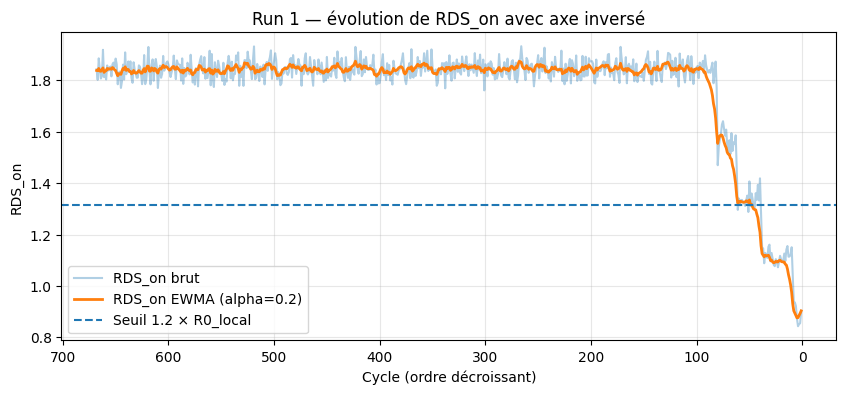

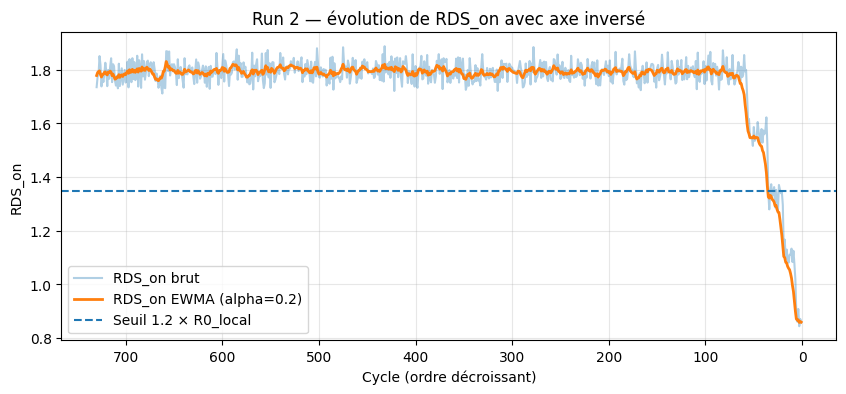

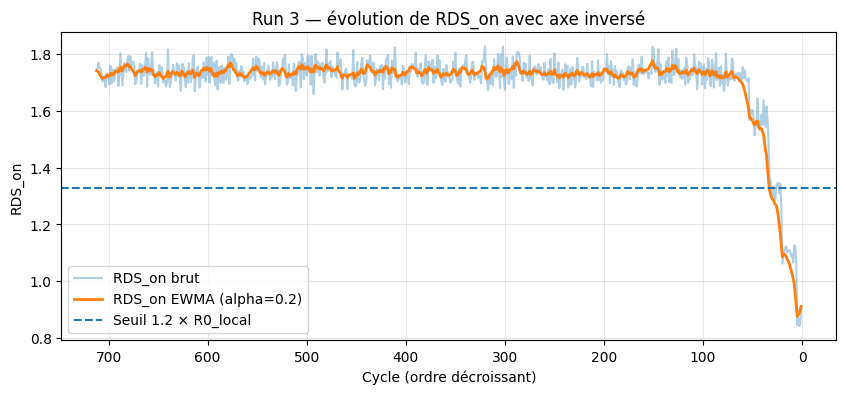

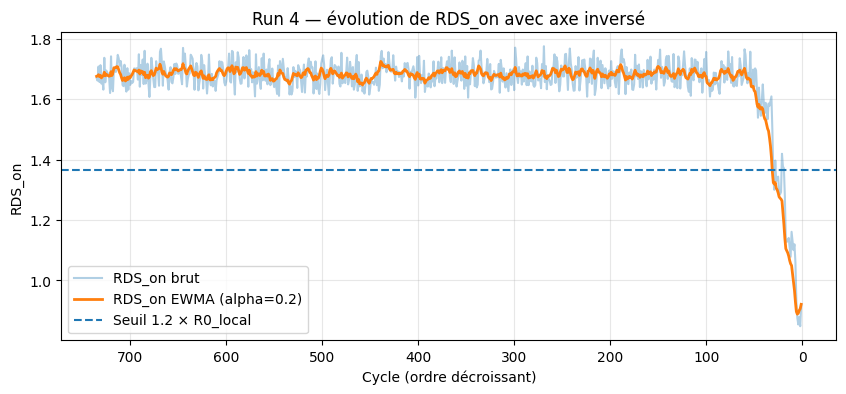

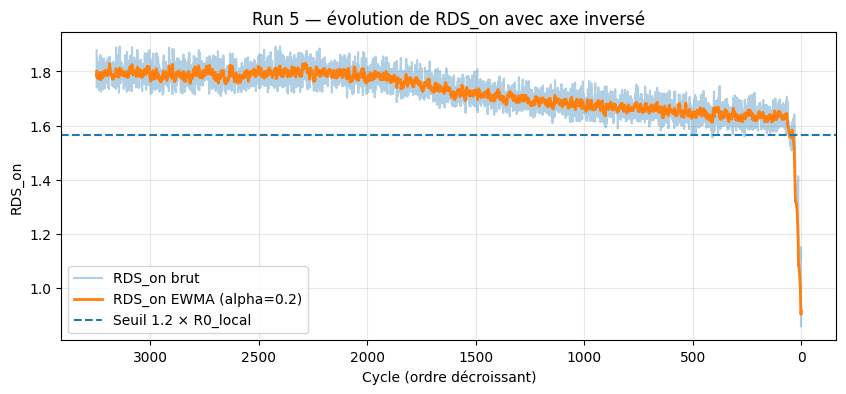

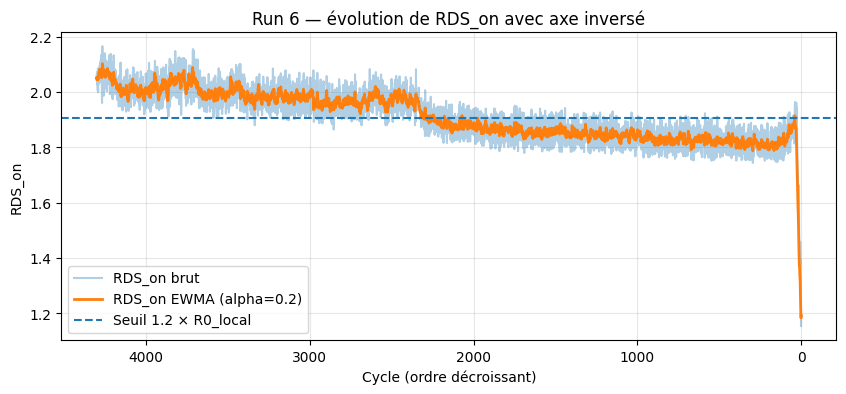

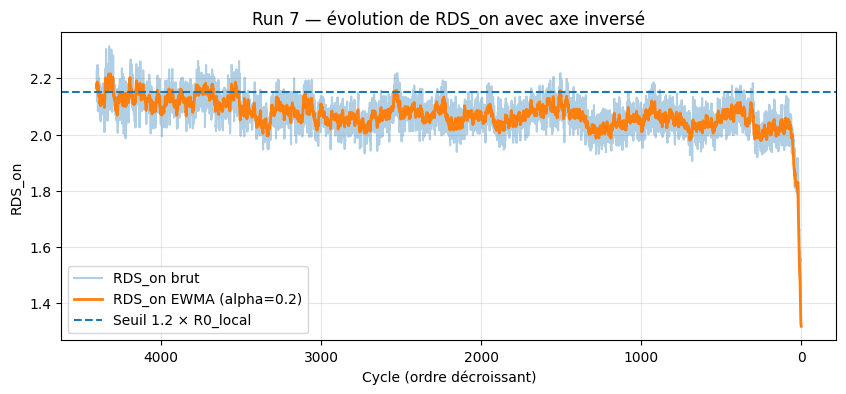

: 

In [ ]:
# ==========================================================
# PARTIE 6 — GRAPHIQUES RDS_on BRUT ET LISSÉ
# ==========================================================
for run_id, g in run_data.items():
    plt.figure(figsize=(10, 4))
    plt.plot(g[CYCLE_COL], g[RDS_COL], alpha=0.35, label="RDS_on brut")
    plt.plot(g[CYCLE_COL], g["RDS_on_EWMA"], linewidth=2, label=f"RDS_on EWMA (alpha={EWMA_ALPHA})")
    plt.axhline(g["R_threshold"].iloc[0], linestyle="--", label="Seuil 1.2 × R0_local")
    plt.gca().invert_xaxis()
    plt.xlabel("Cycle (ordre décroissant)")
    plt.ylabel("RDS_on")
    plt.title(f"Run {run_id} — évolution de RDS_on avec axe inversé")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## PARTIE 7 — Calcul de `N_fail` par deux méthodes

- **Méthode directe** : premier franchissement du seuil sur `RDS_on_EWMA`.
- **Méthode power model** : ajustement de la loi `R(N) = R0 + k·N^β`, puis calcul du cycle de franchissement du seuil.

La suite du notebook **utilisera la méthode directe comme RUL cible pour le LSTM**.


In [7]:
# ==========================================================
# PARTIE 7 — CALCUL DE N_fail PAR DEUX MÉTHODES
# ==========================================================
diag_rows = []

for run_id, g in run_data.items():
    cycles = g[CYCLE_COL].to_numpy(dtype=float)
    r_ewma = g["RDS_on_EWMA"].to_numpy(dtype=float)
    r0_local = float(g["R0_local"].iloc[0])
    r_threshold = float(g["R_threshold"].iloc[0])

    # --- méthode directe
    nfail_direct = first_consecutive_crossing(
        cycles, r_ewma, r_threshold, consecutive_points=CONSECUTIVE_POINTS
    )

    # --- méthode power model
    popt = fit_power_model(cycles, r_ewma, r0_init=r0_local)

    if popt is None:
        r0_fit, k_fit, beta_fit = np.nan, np.nan, np.nan
        nfail_power = np.nan
        rmse_fit, mae_fit, r2_fit = np.nan, np.nan, np.nan
    else:
        r0_fit, k_fit, beta_fit = popt
        nfail_power = nfail_from_power_model(r0_fit, k_fit, beta_fit, r_threshold)

        y_fit = power_model(cycles, r0_fit, k_fit, beta_fit)
        fit_scores = fit_metrics(r_ewma, y_fit)
        rmse_fit = fit_scores["RMSE"]
        mae_fit = fit_scores["MAE"]
        r2_fit = fit_scores["R2"]

    diag_rows.append({
        "run_id": int(run_id),
        "cycle_max_observed": int(np.nanmax(cycles)),
        "R0_local": r0_local,
        "R_threshold": r_threshold,
        "N_fail_direct": nfail_direct,
        "N_fail_power": nfail_power,
        "R0_fit": r0_fit,
        "k_fit": k_fit,
        "beta_fit": beta_fit,
        "power_fit_RMSE": rmse_fit,
        "power_fit_MAE": mae_fit,
        "power_fit_R2": r2_fit,
    })

diag_df = pd.DataFrame(diag_rows).sort_values("run_id").reset_index(drop=True)
display(diag_df)


,run_id,cycle_max_observed,R0_local,R_threshold,N_fail_direct,N_fail_power,R0_fit,k_fit,beta_fit,power_fit_RMSE,power_fit_MAE,power_fit_R2
0,1,668,1.095089,1.314106,48,14.970170,4.566282e-15,0.991064,0.104260,0.123775,0.097522,0.660559
1,2,730,1.124271,1.349125,36,6.309488,4.789147e-01,0.723810,0.100000,0.104783,0.073630,0.545764
2,3,712,1.107831,1.329397,34,5.309720,5.638414e-01,0.647843,0.100000,0.096717,0.067842,0.529109
3,4,735,1.137038,1.364446,32,5.994122,7.462956e-01,0.516799,0.100000,0.087644,0.059136,0.467179
4,5,3248,1.304521,1.565426,40,154.317780,8.966272e-01,0.404067,0.100000,0.038699,0.023831,0.789889
5,6,4301,1.589130,1.906956,2242,2109.232468,1.783257e+00,0.000030,1.088315,0.039616,0.022139,0.797209
6,7,4404,1.792603,2.151124,3529,9638.520597,1.645139e+00,0.202179,0.100000,0.045509,0.031008,0.420091


## PARTIE 8 — Visualisation de `N_fail` sur les courbes

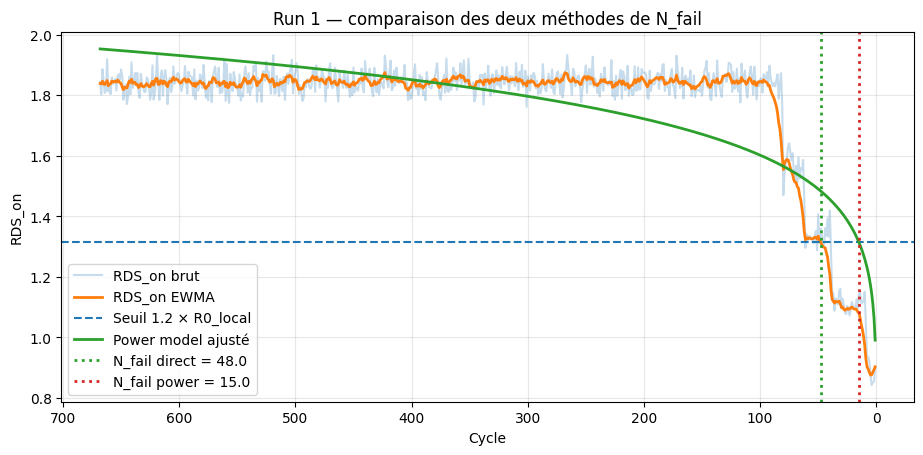

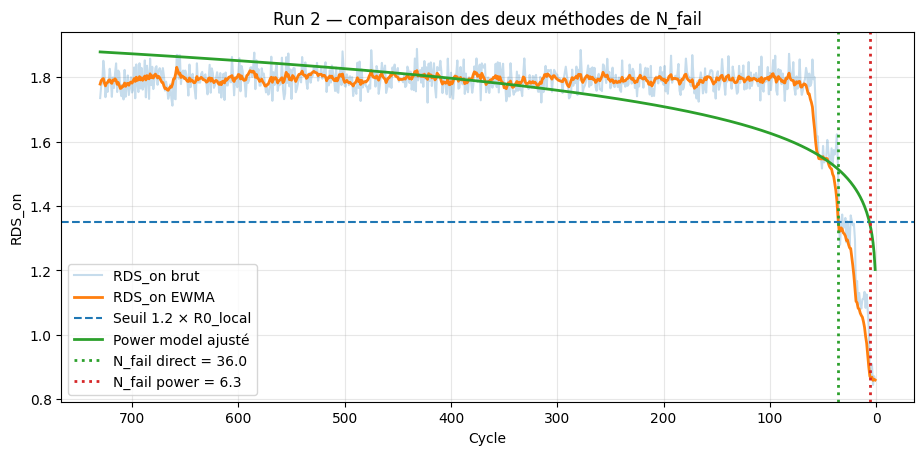

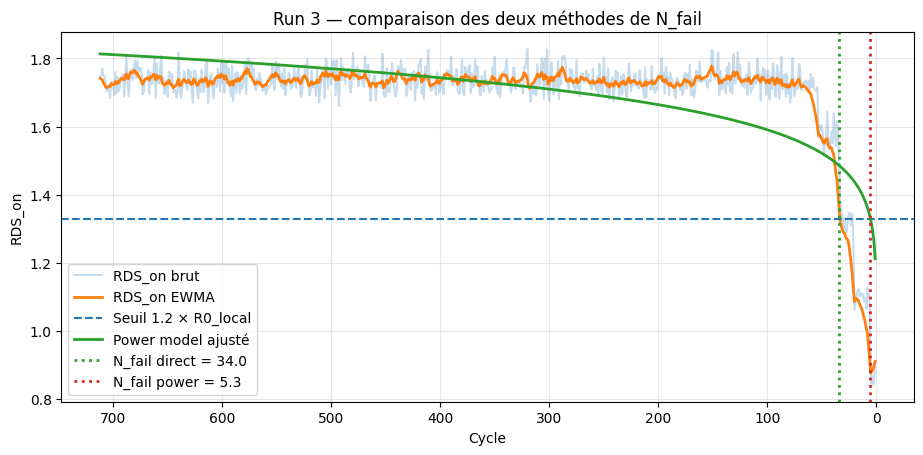

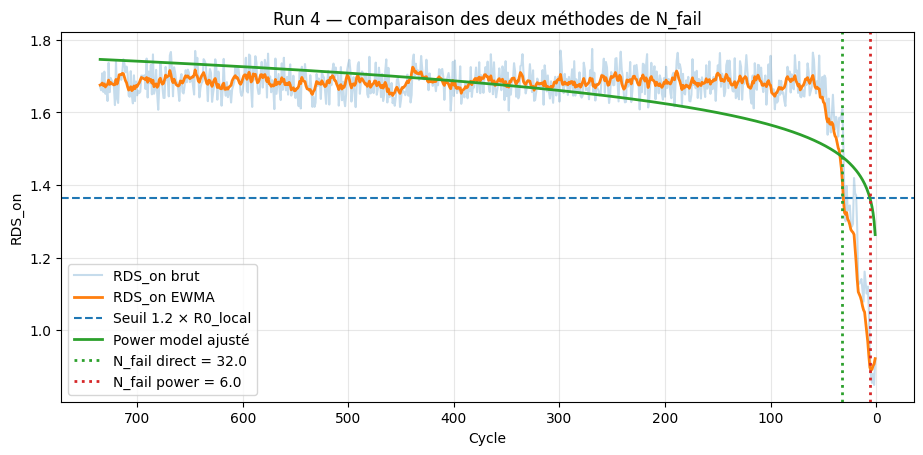

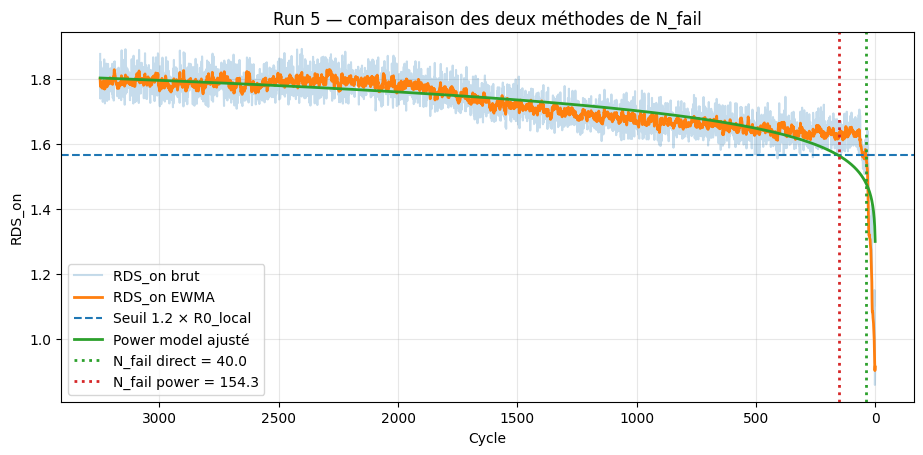

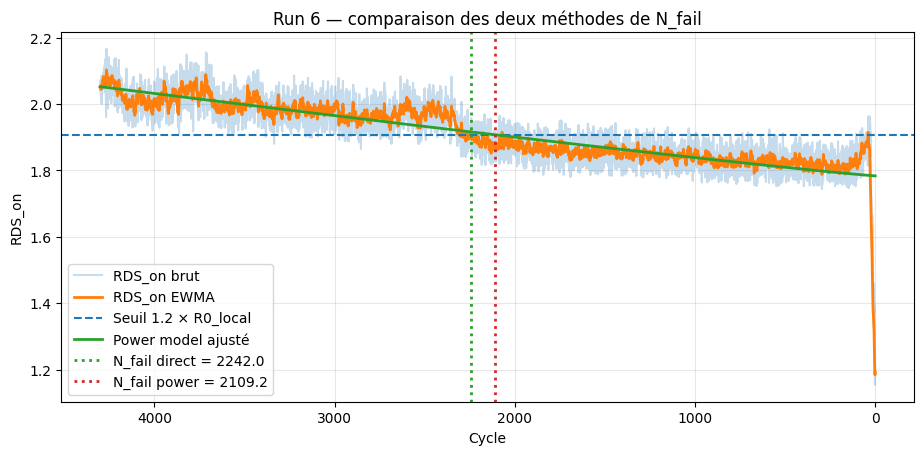

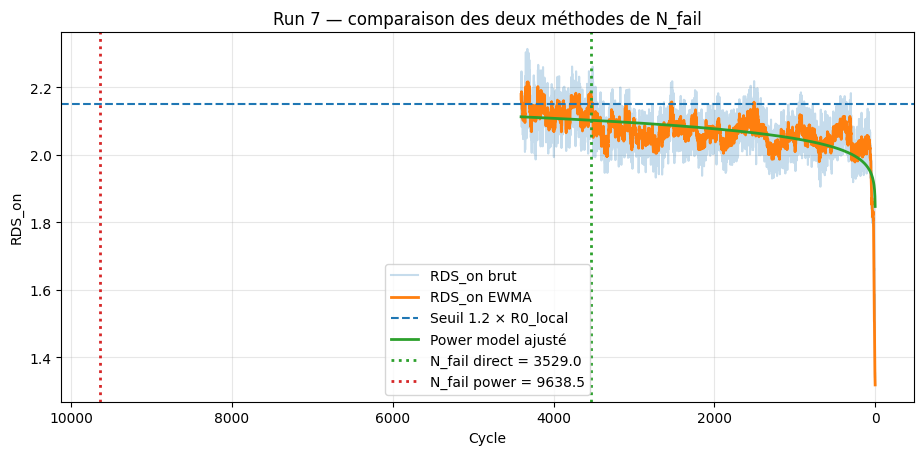

In [17]:
# ==========================================================
# PARTIE 8 — VISUALISATION DES DEUX MÉTHODES DE N_fail
# ==========================================================
for _, row in diag_df.iterrows():
    run_id = int(row["run_id"])
    g = run_data[run_id].copy()
    cycles = g[CYCLE_COL].to_numpy()
    r_raw = g[RDS_COL].to_numpy()
    r_ewma = g["RDS_on_EWMA"].to_numpy()

    plt.figure(figsize=(11, 4.8))
    plt.plot(cycles, r_raw, alpha=0.25, label="RDS_on brut")
    plt.plot(cycles, r_ewma, linewidth=2, label="RDS_on EWMA")
    plt.axhline(row["R_threshold"], linestyle="--", label="Seuil 1.2 × R0_local")

    if np.isfinite(row["R0_fit"]) and np.isfinite(row["k_fit"]) and np.isfinite(row["beta_fit"]):
        y_fit = power_model(cycles, row["R0_fit"], row["k_fit"], row["beta_fit"])
        plt.plot(cycles, y_fit, linewidth=2, label="Power model ajusté")

    if np.isfinite(row["N_fail_direct"]):
        plt.axvline(row["N_fail_direct"], color="tab:green", linestyle=":", linewidth=2,
                    label=f"N_fail direct = {row['N_fail_direct']:.1f}")

    if np.isfinite(row["N_fail_power"]):
        plt.axvline(row["N_fail_power"], color="tab:red", linestyle=":", linewidth=2,
                    label=f"N_fail power = {row['N_fail_power']:.1f}")

    plt.gca().invert_xaxis()   # <-- inversion de l’axe des cycles

    plt.xlabel("Cycle")
    plt.ylabel("RDS_on")
    plt.title(f"Run {run_id} — comparaison des deux méthodes de N_fail")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


## PARTIE 9 — Construction de la RUL par run

On construit deux RUL :
- `RUL_direct` : utilisée comme cible pour l'apprentissage,
- `RUL_power` : conservée pour comparaison.

Ensuite, pour le **LSTM**, on retient **uniquement `RUL_direct`**.
De plus, pour éviter d'ajouter des points après la panne estimée, on ne garde pour chaque run que les cycles **jusqu'à `N_fail_direct`**.


In [9]:
# ==========================================================
# PARTIE 9 — CONSTRUCTION DES RUL PAR RUN
# ==========================================================
rul_frames = []

for _, row in diag_df.iterrows():
    run_id = int(row["run_id"])
    g = run_data[run_id].copy()

    g["N_fail_direct"] = row["N_fail_direct"]
    g["N_fail_power"] = row["N_fail_power"]

    g["RUL_direct_raw"] = row["N_fail_direct"] - g[CYCLE_COL] if np.isfinite(row["N_fail_direct"]) else np.nan
    g["RUL_power_raw"]  = row["N_fail_power"]  - g[CYCLE_COL] if np.isfinite(row["N_fail_power"])  else np.nan

    g["RUL_direct"] = np.maximum(g["RUL_direct_raw"], 0) if np.isfinite(row["N_fail_direct"]) else np.nan
    g["RUL_power"]  = np.maximum(g["RUL_power_raw"], 0)  if np.isfinite(row["N_fail_power"])  else np.nan

    rul_frames.append(g)

df_rul = pd.concat(rul_frames, axis=0).reset_index(drop=True)

display(
    df_rul[[UNIT_COL, CYCLE_COL, RDS_COL, "RDS_on_EWMA", "N_fail_direct", "N_fail_power", "RUL_direct", "RUL_power"]].head(20)
)


,run_id,cycle_current,RDS_on_raw_cycle,RDS_on_EWMA,N_fail_direct,N_fail_power,RUL_direct,RUL_power
0,1,1,0.903046,0.903046,48.0,14.97017,47.0,13.97017
1,1,2,0.854859,0.893409,48.0,14.97017,46.0,12.97017
2,1,3,0.851112,0.884949,48.0,14.97017,45.0,11.97017
3,1,4,0.843240,0.876607,48.0,14.97017,44.0,10.97017
4,1,5,0.873469,0.875980,48.0,14.97017,43.0,9.97017
5,1,6,0.921906,0.885165,48.0,14.97017,42.0,8.97017
6,1,7,0.936052,0.895342,48.0,14.97017,41.0,7.97017
7,1,8,0.935438,0.903362,48.0,14.97017,40.0,6.97017
8,1,9,1.039322,0.930554,48.0,14.97017,39.0,5.97017
9,1,10,1.150574,0.974558,48.0,14.97017,38.0,4.97017


## PARTIE 10 — Visualisation des courbes de RUL par run

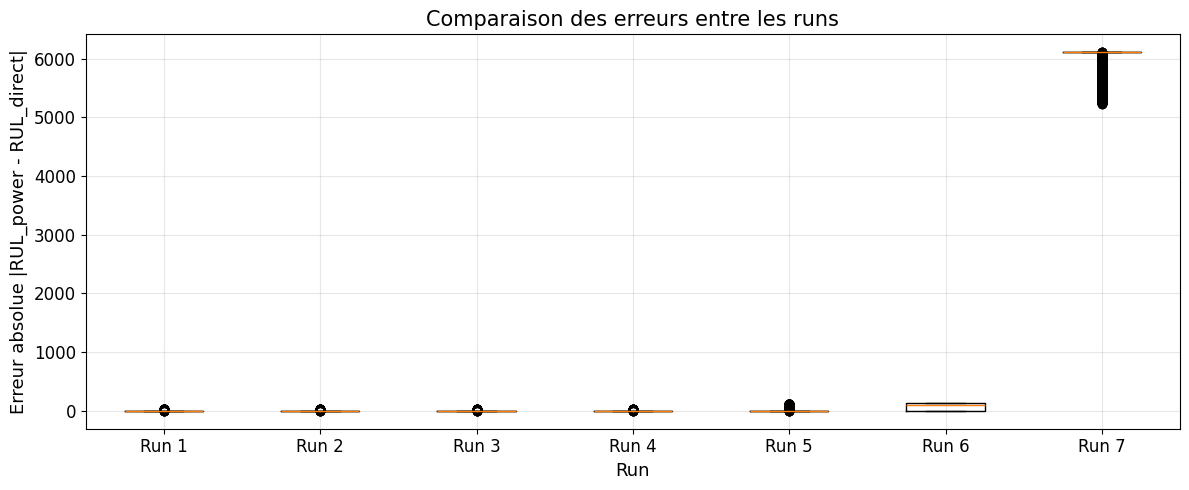

In [10]:
# ==========================================================
# PARTIE 10 — BOXPLOT DE L'ERREUR ABSOLUE PAR RUN
# ==========================================================
import matplotlib.pyplot as plt

df_err = df_rul[[UNIT_COL, "RUL_direct", "RUL_power"]].copy()
df_err = df_err.dropna(subset=["RUL_direct", "RUL_power"])
df_err["error_abs"] = (df_err["RUL_power"] - df_err["RUL_direct"]).abs()

data_abs = []
labels_abs = []

for run_id, g in df_err.groupby(UNIT_COL):
    if len(g) > 0:
        data_abs.append(g["error_abs"].values)
        labels_abs.append(f"Run {int(run_id)}")

plt.figure(figsize=(12, 5))
plt.boxplot(data_abs, labels=labels_abs, showfliers=True)

plt.xlabel("Run", fontsize=13)
plt.ylabel("Erreur absolue |RUL_power - RUL_direct|", fontsize=13)
plt.title("Comparaison des erreurs entre les runs", fontsize=15)

plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PARTIE 11 — Préparation des données pour le LSTM

La cible retenue est :

\[
RUL_{target} = RUL_{direct}
\]

Règles retenues :
- on ne garde que les runs pour lesquels `N_fail_direct` est défini,
- pour chaque run, on ne conserve que les cycles **jusqu'à `N_fail_direct`**,
- on fait un split **par run**,
- les séquences sont construites par fenêtre glissante.


In [11]:
# ==========================================================
# PARTIE 11 — PRÉPARATION DES DONNÉES POUR LE LSTM
# ==========================================================
df_lstm = df_rul.copy()

# On conserve uniquement les runs pour lesquels N_fail_direct est défini
df_lstm = df_lstm[df_lstm["N_fail_direct"].notna()].copy()

# On conserve uniquement les observations jusqu'à la panne directe estimée
df_lstm = df_lstm[df_lstm[CYCLE_COL] <= df_lstm["N_fail_direct"]].copy()

# ==========================================================
# PARTIE 11.0 — CONSTRUCTION DE FEATURES RELATIVES AU RUN
# ==========================================================
required_cols = ["R0_local", "N_fail_direct", CYCLE_COL, "RDS_on_raw_cycle", "RDS_on_EWMA"]
for col in required_cols:
    if col not in df_lstm.columns:
        raise ValueError(f"Colonne manquante pour la partie LSTM : {col}")

# Seuil de défaillance propre à chaque run
df_lstm["R_threshold_local"] = FAILURE_FACTOR * df_lstm["R0_local"]

# Variables relatives au comportement initial du run
df_lstm["RDS_ratio_raw"] = df_lstm["RDS_on_raw_cycle"] / df_lstm["R0_local"]
df_lstm["RDS_ratio_ewma"] = df_lstm["RDS_on_EWMA"] / df_lstm["R0_local"]

# Distance au seuil de défaillance
df_lstm["distance_to_fail_raw"] = df_lstm["R_threshold_local"] - df_lstm["RDS_on_raw_cycle"]
df_lstm["distance_to_fail_ewma"] = df_lstm["R_threshold_local"] - df_lstm["RDS_on_EWMA"]
df_lstm["distance_to_fail_ratio"] = (df_lstm["R_threshold_local"] - df_lstm["RDS_on_EWMA"]) / df_lstm["R0_local"]

# Progression relative dans la vie du composant
df_lstm["cycle_ratio"] = df_lstm[CYCLE_COL] / df_lstm["N_fail_direct"]

# RUL normalisée (utile pour analyse, pas utilisée comme cible ici)
df_lstm["RUL_norm"] = df_lstm["RUL_direct"] / df_lstm["N_fail_direct"]

# Nettoyage des valeurs infinies / NaN éventuelles
df_lstm = df_lstm.replace([np.inf, -np.inf], np.nan).copy()

print("Dimensions de df_lstm :", df_lstm.shape)
print("Runs retenus :", sorted(df_lstm[UNIT_COL].unique().tolist()))

display(df_lstm.head())


Dimensions de df_lstm : (5961, 31)
Runs retenus : [1, 2, 3, 4, 5, 6, 7]


,test_id,run_id,cycle_current,timeEpoch,steady_t_seconds,t_seconds,RDS_on_raw_cycle,RDS_on_raw_mean,drainCurrent_cycle,drainSourceVoltage_cycle,n_rows_steady,packageTemperature_cycle,flangeTemperature_cycle,supplyVoltage_cycle,RDS_on_EWMA,R0_local,R_threshold,N_fail_direct,N_fail_power,RUL_direct_raw,RUL_power_raw,RUL_direct,RUL_power,R_threshold_local,RDS_ratio_raw,RDS_ratio_ewma,distance_to_fail_raw,distance_to_fail_ewma,distance_to_fail_ratio,cycle_ratio,RUL_norm
0,9,1,1,734208.682029,10.439000,10.733999,0.903046,0.903046,5.019703,4.533022,1,36.052743,40.376827,5.608879,0.903046,1.095089,1.314106,48.0,14.97017,47.0,13.97017,47.0,13.97017,1.314106,0.824633,0.824633,0.411060,0.411060,0.375367,0.020833,0.979167
1,9,1,2,734208.682136,19.670996,19.966991,0.854859,0.854859,5.243254,4.482244,1,36.603666,40.514602,5.603089,0.893409,1.095089,1.314106,48.0,14.97017,46.0,12.97017,46.0,12.97017,1.314106,0.780630,0.815832,0.459247,0.420698,0.384168,0.041667,0.958333
2,9,1,3,734208.682263,30.678993,30.978991,0.851112,0.851112,5.261381,4.478025,1,36.527576,40.481970,5.603061,0.884949,1.095089,1.314106,48.0,14.97017,45.0,11.97017,45.0,11.97017,1.314106,0.777208,0.808108,0.462994,0.429157,0.391892,0.062500,0.937500
3,9,1,4,734208.682398,42.317996,42.612000,0.843240,0.843240,5.299018,4.468342,1,36.534862,40.428717,5.603131,0.876607,1.095089,1.314106,48.0,14.97017,44.0,10.97017,44.0,10.97017,1.314106,0.770020,0.800490,0.470867,0.437499,0.399510,0.083333,0.916667
4,9,1,5,734208.682537,54.356997,54.653998,0.873469,0.873469,5.157148,4.504611,1,36.580354,40.509295,5.603354,0.875980,1.095089,1.314106,48.0,14.97017,43.0,9.97017,43.0,9.97017,1.314106,0.797624,0.799917,0.440637,0.438127,0.400083,0.104167,0.895833


In [12]:
# ==========================================================
# PARTIE 11.1 — SPLIT PAR RUN
# Train = tous les runs sauf le dernier
# Test  = dernier run
# ==========================================================
valid_runs = sorted(df_lstm[UNIT_COL].unique().tolist())

if len(valid_runs) < 2:
    raise ValueError("Il faut au moins 2 runs valides pour faire train / test.")

train_runs = valid_runs[:-1]
test_runs = [valid_runs[-1]]

train_df = df_lstm[df_lstm[UNIT_COL].isin(train_runs)].copy().reset_index(drop=True)
test_df  = df_lstm[df_lstm[UNIT_COL].isin(test_runs)].copy().reset_index(drop=True)

print("Train runs :", train_runs)
print("Test runs  :", test_runs)
print("Tailles -> train:", train_df.shape, " | test:", test_df.shape)

print("Train RUL min / max / mean :",
      train_df["RUL_direct"].min(),
      train_df["RUL_direct"].max(),
      train_df["RUL_direct"].mean())

print("Test RUL min / max / mean :",
      test_df["RUL_direct"].min(),
      test_df["RUL_direct"].max(),
      test_df["RUL_direct"].mean())


Train runs : [1, 2, 3, 4, 5, 6]
Test runs  : [7]
Tailles -> train: (2432, 31)  | test: (3529, 31)
Train RUL min / max / mean : 0.0 2241.0 1034.439144736842
Test RUL min / max / mean : 0.0 3528.0 1764.0


In [13]:
# ==========================================================
# PARTIE 11.2 — CHOIX ET NORMALISATION DES FEATURES
# ==========================================================
feature_cols = [
    CYCLE_COL,
    #"cycle_ratio",
    "R0_local",
    #"R_threshold_local",
    #"RDS_on_raw_cycle",
    #"RDS_on_EWMA",
    #"RDS_ratio_raw",
    #"RDS_ratio_ewma",
    #"distance_to_fail_raw",
    #"distance_to_fail_ewma",
    ##"distance_to_fail_ratio",
    "drainCurrent_cycle",
    "drainSourceVoltage_cycle",
    "packageTemperature_cycle",
    "flangeTemperature_cycle",
    "supplyVoltage_cycle",
]

# On retire les colonnes absentes
feature_cols = [c for c in feature_cols if c in train_df.columns]

# Suppression de lignes avec NaN sur les features ou la cible
train_df = train_df.dropna(subset=feature_cols + ["RUL_direct"]).copy().reset_index(drop=True)
test_df  = test_df.dropna(subset=feature_cols + ["RUL_direct"]).copy().reset_index(drop=True)

print("Nombre de features retenues :", len(feature_cols))
print("Features retenues :", feature_cols)
print("Train shape après dropna :", train_df.shape)
print("Test  shape après dropna :", test_df.shape)

x_scaler = StandardScaler()

train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

# On conserve le vrai cycle pour les graphes finaux
train_df_scaled["cycle_true"] = train_df[CYCLE_COL].values
test_df_scaled["cycle_true"]  = test_df[CYCLE_COL].values

train_df_scaled[feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
test_df_scaled[feature_cols]  = x_scaler.transform(test_df[feature_cols])

# Cible non normalisée
train_df_scaled["RUL_target"] = train_df["RUL_direct"].values
test_df_scaled["RUL_target"]  = test_df["RUL_direct"].values

display(train_df_scaled.head())


Nombre de features retenues : 7
Features retenues : ['cycle_current', 'R0_local', 'drainCurrent_cycle', 'drainSourceVoltage_cycle', 'packageTemperature_cycle', 'flangeTemperature_cycle', 'supplyVoltage_cycle']
Train shape après dropna : (2432, 31)
Test  shape après dropna : (3529, 31)


,test_id,run_id,cycle_current,timeEpoch,steady_t_seconds,t_seconds,RDS_on_raw_cycle,RDS_on_raw_mean,drainCurrent_cycle,drainSourceVoltage_cycle,n_rows_steady,packageTemperature_cycle,flangeTemperature_cycle,supplyVoltage_cycle,RDS_on_EWMA,R0_local,R_threshold,N_fail_direct,N_fail_power,RUL_direct_raw,RUL_power_raw,RUL_direct,RUL_power,R_threshold_local,RDS_ratio_raw,RDS_ratio_ewma,distance_to_fail_raw,distance_to_fail_ewma,distance_to_fail_ratio,cycle_ratio,RUL_norm,cycle_true,RUL_target
0,9,1,-1.503199,734208.682029,10.439000,10.733999,0.903046,0.903046,5.467301,-5.432928,1,-5.241856,-5.513133,1.369248,0.903046,-3.871474,1.314106,48.0,14.97017,47.0,13.97017,47.0,13.97017,1.314106,0.824633,0.824633,0.411060,0.411060,0.375367,0.020833,0.979167,1,47.0
1,9,1,-1.501746,734208.682136,19.670996,19.966991,0.854859,0.854859,6.024752,-6.041192,1,-5.210358,-5.508364,-0.396653,0.893409,-3.871474,1.314106,48.0,14.97017,46.0,12.97017,46.0,12.97017,1.314106,0.780630,0.815832,0.459247,0.420698,0.384168,0.041667,0.958333,2,46.0
2,9,1,-1.500292,734208.682263,30.678993,30.978991,0.851112,0.851112,6.069955,-6.091728,1,-5.214708,-5.509493,-0.405164,0.884949,-3.871474,1.314106,48.0,14.97017,45.0,11.97017,45.0,11.97017,1.314106,0.777208,0.808108,0.462994,0.429157,0.391892,0.062500,0.937500,3,45.0
3,9,1,-1.498839,734208.682398,42.317996,42.612000,0.843240,0.843240,6.163805,-6.207714,1,-5.214292,-5.511337,-0.383888,0.876607,-3.871474,1.314106,48.0,14.97017,44.0,10.97017,44.0,10.97017,1.314106,0.770020,0.800490,0.470867,0.437499,0.399510,0.083333,0.916667,4,44.0
4,9,1,-1.497386,734208.682537,54.356997,54.653998,0.873469,0.873469,5.810037,-5.773264,1,-5.211691,-5.508548,-0.315805,0.875980,-3.871474,1.314106,48.0,14.97017,43.0,9.97017,43.0,9.97017,1.314106,0.797624,0.799917,0.440637,0.438127,0.400083,0.104167,0.895833,5,43.0


## PARTIE 12 — Recherche d'hyperparamètres du LSTM

On remplace le test simple de quelques fenêtres par une **recherche structurée d'hyperparamètres**.

Les combinaisons testées portent sur :
- la taille de fenêtre,
- le nombre d'unités LSTM,
- le taux de dropout,
- la taille de la couche dense,
- le learning rate,
- le batch size.

Le meilleur jeu de paramètres est choisi sur la base de la **RMSE de validation**, puis réutilisé pour entraîner le modèle final.


In [14]:
# ==========================================================
# PARTIE 12 — RECHERCHE D'HYPERPARAMÈTRES DU LSTM
# ==========================================================
from itertools import product

grid_results = []
best_config = None
best_predictions = None
trial_id = 0

param_grid = list(product(
    WINDOW_SIZES,
    LSTM_UNITS_GRID,
    DROPOUT_GRID,
    DENSE_UNITS_GRID,
    LEARNING_RATE_GRID,
    BATCH_SIZE_GRID,
))

if MAX_GRID_TRIALS is not None:
    param_grid = param_grid[:MAX_GRID_TRIALS]

print(f"Nombre de combinaisons testées : {len(param_grid)}")

for (window_size, lstm_units, dropout_rate, dense_units, learning_rate, batch_size) in param_grid:
    trial_id += 1
    print("=" * 100)
    print(
        f"Essai {trial_id} | window={window_size} | lstm_units={lstm_units} | "
        f"dropout={dropout_rate} | dense_units={dense_units} | lr={learning_rate} | batch={batch_size}"
    )

    X_train, y_train, meta_train = build_sequences_by_runs(
        train_df_scaled, feature_cols, "RUL_target", window_size
    )
    X_test, y_test, meta_test = build_sequences_by_runs(
        test_df_scaled, feature_cols, "RUL_target", window_size
    )

    print("Shapes -> X_train:", X_train.shape, "| X_test:", X_test.shape)

    if len(X_train) == 0 or len(X_test) == 0:
        print("Pas assez de données pour cette combinaison. On passe.")
        continue

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    model = build_lstm_model(
        window_size=window_size,
        n_features=len(feature_cols),
        lstm_units=lstm_units,
        dropout_rate=dropout_rate,
        dense_units=dense_units,
        learning_rate=learning_rate,
    )

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=PATIENCE_ES, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=PATIENCE_LR, min_lr=1e-5)
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=EPOCHS_GRID,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks
    )

    y_pred_train = np.clip(model.predict(X_train, verbose=0).ravel(), 0, None)
    y_pred_test = np.clip(model.predict(X_test, verbose=0).ravel(), 0, None)

    y_train_true = y_train.ravel()
    y_test_true = y_test.ravel()

    rmse_train, mae_train, r2_train = regression_metrics(y_train_true, y_pred_train)
    rmse_test, mae_test, r2_test = regression_metrics(y_test_true, y_pred_test)
    sax_total_test, sax_mean_test = saxena_score(y_test_true, y_pred_test)

    val_loss_history = history.history.get("val_loss", [])
    best_val_loss = float(np.min(val_loss_history)) if len(val_loss_history) else np.nan
    best_epoch = int(np.argmin(val_loss_history) + 1) if len(val_loss_history) else np.nan

    row = {
        "trial_id": trial_id,
        "window_size": window_size,
        "lstm_units": lstm_units,
        "dropout_rate": dropout_rate,
        "dense_units": dense_units,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "RMSE_train": rmse_train,
        "RMSE_test": rmse_test,
        "MAE_test": mae_test,
        "R2_test": r2_test,
        "Saxena_total_test": sax_total_test,
        "Saxena_mean_test": sax_mean_test,
        "n_seq_train": len(X_train),
        "n_seq_test": len(X_test),
    }
    grid_results.append(row)

    if best_config is None or best_val_loss < best_config["best_val_loss"]:
        best_config = row.copy()
        best_predictions = {
            "meta_train": meta_train.copy(),
            "meta_test": meta_test.copy(),
            "y_train_true": y_train_true.copy(),
            "y_train_pred": y_pred_train.copy(),
            "y_test_true": y_test_true.copy(),
            "y_test_pred": y_pred_test.copy(),
            "history": history.history,
        }

if len(grid_results) == 0:
    raise ValueError("Aucune combinaison d'hyperparamètres n'a pu être évaluée.")

grid_results_df = pd.DataFrame(grid_results).sort_values(
    by=["best_val_loss", "RMSE_test", "MAE_test"],
    ascending=[True, True, True]
).reset_index(drop=True)

print("\nTop 10 des meilleures combinaisons :")
display(grid_results_df.head(10))

print("\nMeilleure configuration retenue :")
display(pd.DataFrame([best_config]))

# ==========================================================
# PARTIE 12.1 — ENTRAÎNEMENT FINAL AVEC LES MEILLEURS HYPERPARAMÈTRES
# ==========================================================
best_window = int(best_config["window_size"])

X_train_best, y_train_best, meta_train_best = build_sequences_by_runs(
    train_df_scaled, feature_cols, "RUL_target", best_window
)
X_test_best, y_test_best, meta_test_best = build_sequences_by_runs(
    test_df_scaled, feature_cols, "RUL_target", best_window
)

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

final_model = build_lstm_model(
    window_size=best_window,
    n_features=len(feature_cols),
    lstm_units=int(best_config["lstm_units"]),
    dropout_rate=float(best_config["dropout_rate"]),
    dense_units=int(best_config["dense_units"]),
    learning_rate=float(best_config["learning_rate"]),
)

final_callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE_ES, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=PATIENCE_LR, min_lr=1e-5)
]

final_history = final_model.fit(
    X_train_best, y_train_best,
    validation_split=0.2,
    epochs=EPOCHS_FINAL,
    batch_size=int(best_config["batch_size"]),
    verbose=0,
    callbacks=final_callbacks
)

y_pred_train_final = np.clip(final_model.predict(X_train_best, verbose=0).ravel(), 0, None)
y_pred_test_final = np.clip(final_model.predict(X_test_best, verbose=0).ravel(), 0, None)

y_train_true_final = y_train_best.ravel()
y_test_true_final = y_test_best.ravel()

rmse_train_final, mae_train_final, r2_train_final = regression_metrics(y_train_true_final, y_pred_train_final)
rmse_test_final, mae_test_final, r2_test_final = regression_metrics(y_test_true_final, y_pred_test_final)
sax_total_final, sax_mean_final = saxena_score(y_test_true_final, y_pred_test_final)

final_results_df = pd.DataFrame([{
    "best_window_size": best_window,
    "best_lstm_units": int(best_config["lstm_units"]),
    "best_dropout_rate": float(best_config["dropout_rate"]),
    "best_dense_units": int(best_config["dense_units"]),
    "best_learning_rate": float(best_config["learning_rate"]),
    "best_batch_size": int(best_config["batch_size"]),
    "RMSE_train_final": rmse_train_final,
    "MAE_train_final": mae_train_final,
    "R2_train_final": r2_train_final,
    "RMSE_test_final": rmse_test_final,
    "MAE_test_final": mae_test_final,
    "R2_test_final": r2_test_final,
    "Saxena_total_test_final": sax_total_final,
    "Saxena_mean_test_final": sax_mean_final,
    "n_seq_train_final": len(X_train_best),
    "n_seq_test_final": len(X_test_best),
}])

predictions_store = {
    best_window: {
        "meta_train": meta_train_best.copy(),
        "meta_test": meta_test_best.copy(),
        "y_train_true": y_train_true_final.copy(),
        "y_train_pred": y_pred_train_final.copy(),
        "y_test_true": y_test_true_final.copy(),
        "y_test_pred": y_pred_test_final.copy(),
        "history": final_history.history,
    }
}

print("\nRésultats finaux avec la meilleure configuration :")
display(final_results_df)


Nombre de combinaisons testées : 128
Essai 1 | window=5 | lstm_units=32 | dropout=0.1 | dense_units=16 | lr=0.001 | batch=16
Shapes -> X_train: (2408, 5, 7) | X_test: (3525, 5, 7)

Essai 2 | window=5 | lstm_units=32 | dropout=0.1 | dense_units=16 | lr=0.001 | batch=32
Shapes -> X_train: (2408, 5, 7) | X_test: (3525, 5, 7)
Essai 3 | window=5 | lstm_units=32 | dropout=0.1 | dense_units=16 | lr=0.0005 | batch=16
Shapes -> X_train: (2408, 5, 7) | X_test: (3525, 5, 7)
Essai 4 | window=5 | lstm_units=32 | dropout=0.1 | dense_units=16 | lr=0.0005 | batch=32
Shapes -> X_train: (2408, 5, 7) | X_test: (3525, 5, 7)
Essai 5 | window=5 | lstm_units=32 | dropout=0.1 | dense_units=32 | lr=0.001 | batch=16
Shapes -> X_train: (2408, 5, 7) | X_test: (3525, 5, 7)
Essai 6 | window=5 | lstm_units=32 | dropout=0.1 | dense_units=32 | lr=0.001 | batch=32
Shapes -> X_train: (2408, 5, 7) | X_test: (3525, 5, 7)
Essai 7 | window=5 | lstm_units=32 | dropout=0.1 | dense_units=32 | lr=0.0005 | batch=16
Shapes -> X_t

,trial_id,window_size,lstm_units,dropout_rate,dense_units,learning_rate,batch_size,best_epoch,best_val_loss,RMSE_train,RMSE_test,MAE_test,R2_test,Saxena_total_test,Saxena_mean_test,n_seq_train,n_seq_test
0,29,5,64,0.2,32,0.0010,16,29,230.703491,20.366318,671.307677,576.148373,0.564783,1.123214e+07,3186.423586,2408,3525
1,21,5,64,0.1,32,0.0010,16,26,265.522339,15.851955,672.187217,584.020613,0.563641,1.488286e+07,4222.088516,2408,3525
2,53,10,64,0.1,32,0.0010,16,29,398.714142,18.752239,888.182950,794.991845,0.235987,9.518342e+06,2704.074517,2378,3520
3,55,10,64,0.1,32,0.0005,16,54,832.903259,44.967616,739.282106,630.039552,0.470682,1.872470e+07,5319.517949,2378,3520
4,33,10,32,0.1,16,0.0010,16,29,875.881775,138.912360,980.908148,837.807764,0.068136,7.869713e+06,2235.713792,2378,3520
5,9,5,32,0.2,16,0.0010,16,39,893.445068,61.043050,830.457336,706.942722,0.333964,1.269585e+07,3601.658994,2408,3525
6,30,5,64,0.2,32,0.0010,32,56,957.825012,40.149326,700.265841,589.292294,0.526425,1.792078e+07,5083.907889,2408,3525
7,54,10,64,0.1,32,0.0010,32,54,1070.717651,51.001509,732.077865,605.867654,0.480948,1.237705e+07,3516.206793,2378,3520
8,25,5,64,0.2,16,0.0010,16,45,1160.034546,26.686346,674.649556,581.183916,0.560439,1.593866e+07,4521.604893,2408,3525
9,73,15,32,0.2,16,0.0010,16,32,1171.015747,114.268006,1021.966191,885.533295,-0.014387,9.255845e+06,2633.241930,2348,3515



Meilleure configuration retenue :


,trial_id,window_size,lstm_units,dropout_rate,dense_units,learning_rate,batch_size,best_epoch,best_val_loss,RMSE_train,RMSE_test,MAE_test,R2_test,Saxena_total_test,Saxena_mean_test,n_seq_train,n_seq_test
0,29,5,64,0.2,32,0.001,16,29,230.703491,20.366318,671.307677,576.148373,0.564783,1.123214e+07,3186.423586,2408,3525



Résultats finaux avec la meilleure configuration :


,best_window_size,best_lstm_units,best_dropout_rate,best_dense_units,best_learning_rate,best_batch_size,RMSE_train_final,MAE_train_final,R2_train_final,RMSE_test_final,MAE_test_final,R2_test_final,Saxena_total_test_final,Saxena_mean_test_final,n_seq_train_final,n_seq_test_final
0,5,64,0.2,32,0.001,16,20.366318,15.199922,0.999113,671.307677,576.148373,0.564783,1.123214e+07,3186.423586,2408,3525


## PARTIE 13 — Courbes `RUL réelle` vs `RUL prédite` sur le test avec le meilleur modèle

Les prédictions tracées ci-dessous correspondent au **modèle final entraîné avec les meilleurs hyperparamètres trouvés par la recherche**.


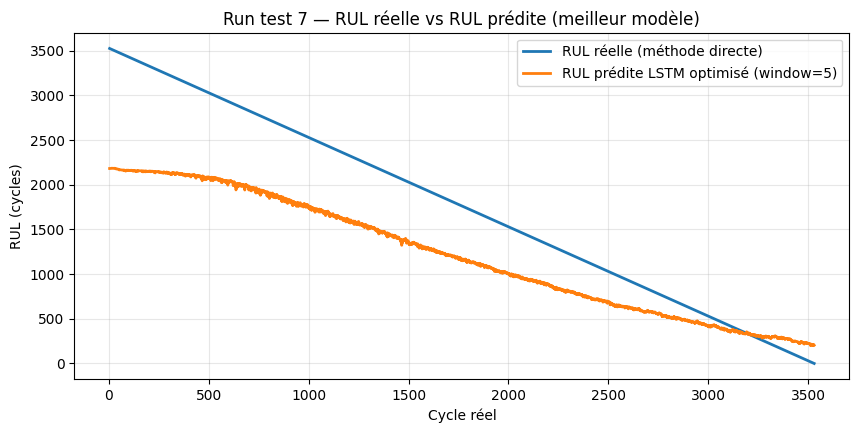

In [15]:
# ==========================================================
# PARTIE 13 — RUL RÉELLE VS RUL PRÉDITE (TEST, MEILLEUR MODÈLE)
# ==========================================================
for window_size, data_dict in predictions_store.items():
    meta_test = data_dict["meta_test"]
    y_true = data_dict["y_test_true"]
    y_pred = data_dict["y_test_pred"]

    cycle_plot_col = "cycle_true" if "cycle_true" in meta_test.columns else CYCLE_COL

    for run_id in sorted(meta_test[UNIT_COL].unique().tolist()):
        mask = meta_test[UNIT_COL].values == run_id

        cycles_plot = meta_test.loc[mask, cycle_plot_col].values
        y_true_plot = y_true[mask]
        y_pred_plot = y_pred[mask]

        order = np.argsort(cycles_plot)
        cycles_plot = cycles_plot[order]
        y_true_plot = y_true_plot[order]
        y_pred_plot = y_pred_plot[order]

        plt.figure(figsize=(10, 4.5))
        plt.plot(cycles_plot, y_true_plot, linewidth=2, label="RUL réelle (méthode directe)")
        plt.plot(cycles_plot, y_pred_plot, linewidth=2, label=f"RUL prédite LSTM optimisé (window={window_size})")
        plt.xlabel("Cycle réel")
        plt.ylabel("RUL (cycles)")
        plt.title(f"Run test {run_id} — RUL réelle vs RUL prédite (meilleur modèle)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()


## PARTIE 14 — Lecture des résultats

### Ce qu'il faut retenir

- `grid_results_df` permet de comparer toutes les combinaisons testées.
- `best_config` contient la meilleure combinaison trouvée pendant la recherche.
- `final_results_df` résume les performances du modèle final réentraîné avec ces hyperparamètres.
- `predictions_store` contient les prédictions finales pour tracer la RUL réelle et prédite.


